# Problem 4.1

Creating a list of the paths to images.

In [24]:
import os
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import cv2

Creating a list of the paths to images.

['./KIMIA dataset\\bonefishes.png', './KIMIA dataset\\bonefishesocc1.png', './KIMIA dataset\\bunny04.png', './KIMIA dataset\\calf1.png', './KIMIA dataset\\calf2.png', './KIMIA dataset\\cat1.png', './KIMIA dataset\\cat2.png', './KIMIA dataset\\cow1.png', './KIMIA dataset\\cow2.png', './KIMIA dataset\\desertcottontail.png', './KIMIA dataset\\dog1.png', './KIMIA dataset\\dog2.png', './KIMIA dataset\\dog3.png', './KIMIA dataset\\dogfishsharks.png', './KIMIA dataset\\donkey1.png', './KIMIA dataset\\dude0.png', './KIMIA dataset\\dude1.png', './KIMIA dataset\\dude10.png', './KIMIA dataset\\dude11.png', './KIMIA dataset\\dude12.png', './KIMIA dataset\\dude2.png', './KIMIA dataset\\dude4.png', './KIMIA dataset\\dude5.png', './KIMIA dataset\\dude6.png', './KIMIA dataset\\dude7.png', './KIMIA dataset\\dude8.png', './KIMIA dataset\\easterncottontail.png', './KIMIA dataset\\f15.png', './KIMIA dataset\\f16.png', './KIMIA dataset\\f16occ1.png', './KIMIA dataset\\fgen1ap.png', './KIMIA dataset\\fgen1b

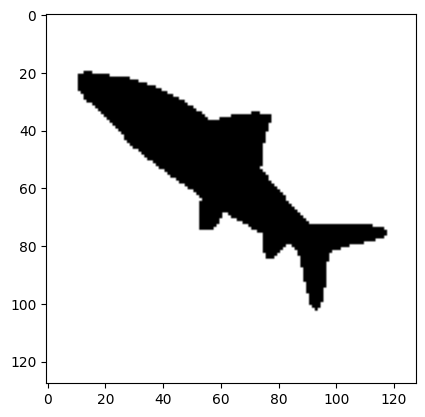

In [25]:

# Function to convert an RGB image to grayscale without using built-in functions
def rgb_to_gray(image):
    image = np.array(image)                                       # Converting image to np array
    r, g, b = image[:, :, 0], image[:, :, 1], image[:, :, 2]      # Getting red, green and blue channels
    gray = 0.2989 * r + 0.5870 * g + 0.1140 * b                   # Weighted average
    gray = gray.astype(np.uint8)                                  # Converting it to b bits for 0-255
    #cv2.imwrite(gray_img, gray)
    #gray_img = Image.fromarray(gray)                              # Converting back to image object
    return gray


folder_path = './KIMIA dataset'

file_list = os.listdir(folder_path)
png_files = [file for file in file_list if file.endswith('.png')]

file_path = []
for png_file in png_files:
    file_path.append(os.path.join(folder_path, png_file))

file_path=sorted(file_path)
print(file_path)

# Showing an example image
image = cv2.imread(file_path[0])
gray_img = rgb_to_gray(image)
print(gray_img.shape)
plt.imshow(gray_img, cmap='gray')

In [26]:
def extract_black(image):
    white=[]
    black=[]
    for i in range(0,image.shape[0]):
        for j in range (0,image.shape[1]):
            if(image[i][j]<10):
                black.append([i,j])  
    black = np.array(black)
    return black

# template_shape = template_shape[:,:,template_shape < 10]
# print(template_shape)

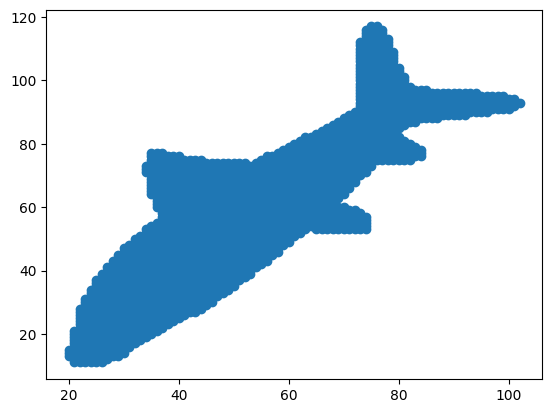

In [27]:
# Define the template shape as a set of points (x, y coordinates)
template_image = cv2.imread(file_path[0])
gray_img = rgb_to_gray(template_image)

template_shape = extract_black(gray_img)
plt.scatter(template_shape[:,0], template_shape[:,1])

# Define the other shape as a set of points (x, y coordinates)
other_shapes = []
for path in file_path:
    other_image = cv2.imread(file_path[8])
    gray_img_other = rgb_to_gray(other_image)
    
    other_shape = extract_black(gray_img_other)
    other_shapes.append(other_shape)


NOTE: This appears to be flipped upside down, but if we match the cordinate of pixels we would find out that the image is correctly oriented. 

In [28]:
# # Define a function to calculate the angle between two vectors
# def angle_between_vectors(vector1, vector2):
#     dot_product = np.dot(vector1, vector2)
#     magnitude1 = np.linalg.norm(vector1)
#     magnitude2 = np.linalg.norm(vector2)
#     return np.degrees(np.arccos(dot_product / (magnitude1 * magnitude2)))

We can find the PCA of the images. <br>
We can find the angle between the two PC1 of both the template and the other image. <br>


In [29]:

import math
from sklearn.preprocessing import StandardScaler

rotation_angles = []

for other_shape in other_shapes: 
    image1_array = template_shape
    image2_array = other_shape
    
    # # Using In-built function
    # scaler = StandardScaler()
    # image1_array = scaler.fit_transform(image1_array_un)
    # image2_array = scaler.fit_transform(image2_array_un)
    
    # Apply PCA to extract the first principal component
    pca1 = PCA(n_components=2)
    pca2 = PCA(n_components=2)
    
    # Fit PCA on the flattened arrays
    pca1.fit(image1_array)
    pca2.fit(image2_array)
    
    # Get the first principal component vectors
    pc1_1 = pca1.components_
    pc1_2 = pca2.components_
    
    # Calculate the angle between the first principal components
    dot_product = np.dot(pc1_1[0], pc1_2[0])
    cosine_similarity = dot_product / (np.linalg.norm(pc1_1[0]) * np.linalg.norm(pc1_2[0]))
    angle_radians = np.arccos(cosine_similarity)
    angle_degrees = math.degrees(angle_radians)
    
    print(f"The angle between the two images is {angle_degrees} degrees.")
    rotation_angles.append(angle_degrees)

The angle between the two images is 24.835510721944136 degrees.
The angle between the two images is 24.835510721944136 degrees.
The angle between the two images is 24.835510721944136 degrees.
The angle between the two images is 24.835510721944136 degrees.
The angle between the two images is 24.835510721944136 degrees.
The angle between the two images is 24.835510721944136 degrees.
The angle between the two images is 24.835510721944136 degrees.
The angle between the two images is 24.835510721944136 degrees.
The angle between the two images is 24.835510721944136 degrees.
The angle between the two images is 24.835510721944136 degrees.
The angle between the two images is 24.835510721944136 degrees.
The angle between the two images is 24.835510721944136 degrees.
The angle between the two images is 24.835510721944136 degrees.
The angle between the two images is 24.835510721944136 degrees.
The angle between the two images is 24.835510721944136 degrees.
The angle between the two images is 24.8

The image is plotted using scatter plot for better visualisation of the angle between them. 


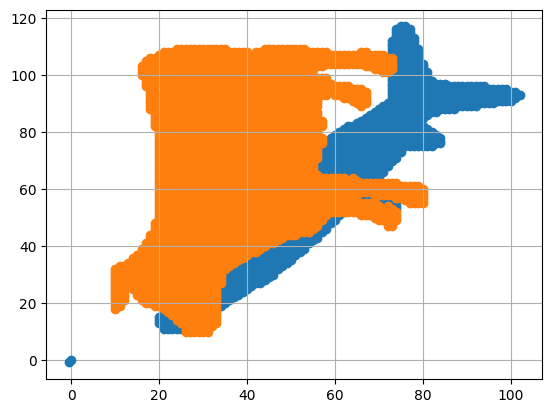

In [30]:

plt.scatter(image1_array[:,0], image1_array[:,1])
plt.scatter(image2_array[:,0], image2_array[:,1])


# Define the two points as (x1, y1) and (x2, y2)
x1, y1 = 0, 0
x2, y2 = pc1_1[0]

# Create a list of x values for the line
x_values = [x1, x2]

# Create a list of y values for the line
y_values = [y1, y2]

# Plot the line
plt.plot(x_values, y_values, marker='o', linestyle='-')


# Display the plot
plt.grid()
plt.show()



We can rotate the other image by the given image using the obtained angle from above. 

In [31]:
import cv2

for i in range(0, len(rotation_angles)):
    # Load the image
    image = cv2.imread(file_path[i])
    
    # Define the rotation angle in degrees
    angle = rotation_angles[i]
    
    # Get the height and width of the image
    height, width = image.shape[:2]
    
    # Calculate the rotation matrix
    rotation_matrix = cv2.getRotationMatrix2D((width / 2, height / 2), angle, 1)
    
    # Apply the rotation to the image using warpAffine
    rotated_image = cv2.warpAffine(image, rotation_matrix, (width, height))
    
    # Display the original and rotated images
    # cv2.imshow('Original Image', image)
    #cv2.imshow('Rotated Image', rotated_image)
    
    output_folder = './output_folder_4_1/'
    output_filename = 'output_image{}.jpg'.format(i)
    output_path = output_folder + output_filename
    
    cv2.imwrite(output_path, rotated_image)



NOTE: I have added an copy of KIMIA Dataset consisting only the 'tools' images. <br>
We can just change the folder name to 'KIMIA dataset-Copy1' in the first cell, to test the code only for the the 'tools' and it works fine. 